# Exploring DEM Files in the TomoSAR Dataset

This notebook explores the **Digital Elevation Model (DEM)** `.npy` files included in the base dataset.  
Two variants are available:
- `dem_full` — full-resolution DEM aligned with the parameter tag
- `dem_reduced` — reduced-resolution DEM aligned with the tomogram tag


## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.dpi"] = 120


## 2. Load the DEM Files

In [2]:
DATA_DIR = Path("/ste/rnd/User/vice_vi/Dataset/base_dataset_w20_10/data")

dem_full    = np.load(DATA_DIR / "dem_full_1000a16000a500a4000_1_Xparams_id2X.npy")
dem_reduced = np.load(DATA_DIR / "dem_reduced_1000a16000a500a4000_dtmf_Xtomo_id2X.npy")

print("dem_full    loaded:", dem_full.shape)
print("dem_reduced loaded:", dem_reduced.shape)


dem_full    loaded: (15000, 3500)
dem_reduced loaded: (15000, 3500)


## 3. Inspect Array Shape and Data Types

In [3]:
for name, arr in [("dem_full", dem_full), ("dem_reduced", dem_reduced)]:
    print(f"── {name} ──")
    print(f"  shape : {arr.shape}")
    print(f"  ndim  : {arr.ndim}")
    print(f"  dtype : {arr.dtype}")
    print(f"  size  : {arr.size:,} elements")
    print()


── dem_full ──
  shape : (15000, 3500)
  ndim  : 2
  dtype : float32
  size  : 52,500,000 elements

── dem_reduced ──
  shape : (15000, 3500)
  ndim  : 2
  dtype : float32
  size  : 52,500,000 elements



## 4. Basic Statistical Analysis

In [4]:
percentiles = [1, 5, 25, 50, 75, 95, 99]

for name, arr in [("dem_full", dem_full), ("dem_reduced", dem_reduced)]:
    flat = arr.ravel()
    valid = flat[np.isfinite(flat)]
    print(f"── {name} ──")
    print(f"  NaN count : {np.isnan(flat).sum():,}")
    print(f"  min       : {valid.min():.4f}")
    print(f"  max       : {valid.max():.4f}")
    print(f"  mean      : {valid.mean():.4f}")
    print(f"  std       : {valid.std():.4f}")
    pcts = np.percentile(valid, percentiles)
    for p, v in zip(percentiles, pcts):
        print(f"  p{p:>2d}       : {v:.4f}")
    print()


── dem_full ──
  NaN count : 0
  min       : 620.6339
  max       : 819.6275
  mean      : 688.8706
  std       : 37.5297
  p 1       : 627.2248
  p 5       : 636.7871
  p25       : 659.1489
  p50       : 683.8825
  p75       : 714.6930
  p95       : 757.5684
  p99       : 796.5395

── dem_reduced ──
  NaN count : 0
  min       : 620.6339
  max       : 819.6275
  mean      : 688.8706
  std       : 37.5297
  p 1       : 627.2248
  p 5       : 636.7871
  p25       : 659.1489
  p50       : 683.8825
  p75       : 714.6930
  p95       : 757.5684
  p99       : 796.5395



## 5. Visualize DEM as 2D Heatmap

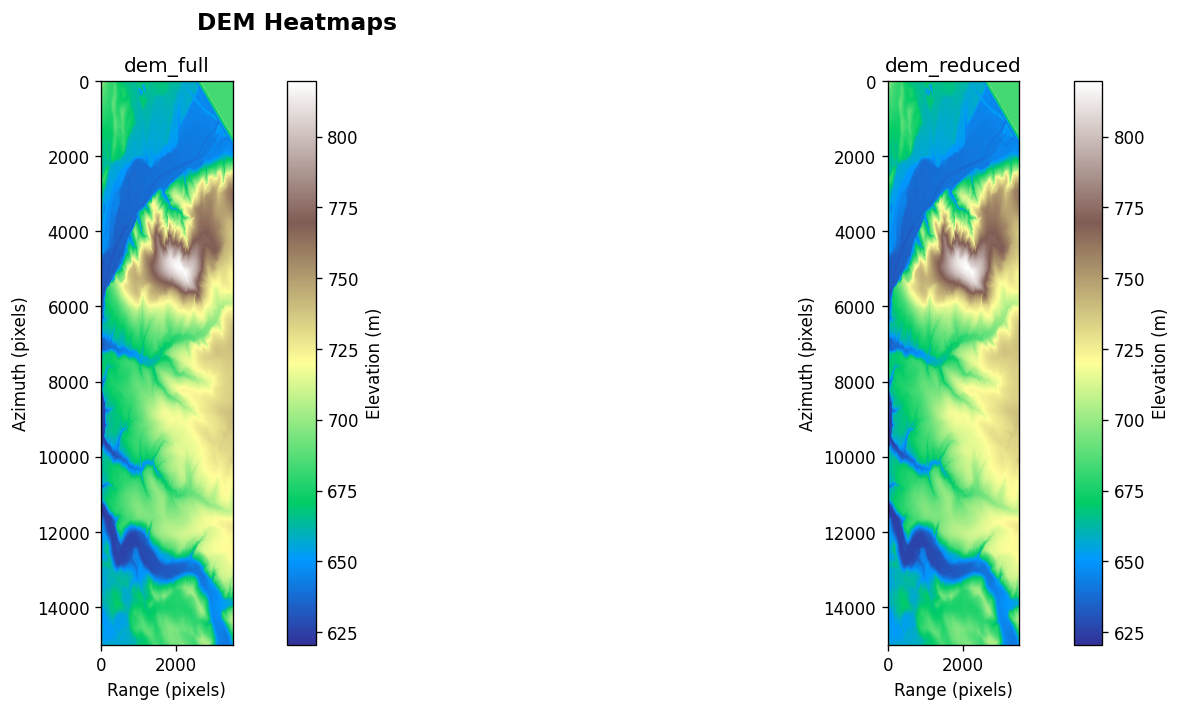

In [5]:
def show_dem(arr, title, ax):
    # If 3-D, take first channel or last channel depending on shape
    if arr.ndim == 3:
        # assume (H, W, C) or (C, H, W) — pick the spatial slice
        img = arr[..., 0] if arr.shape[-1] < arr.shape[0] else arr[0]
    else:
        img = arr
    im = ax.imshow(img, cmap="terrain", interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Range (pixels)")
    ax.set_ylabel("Azimuth (pixels)")
    plt.colorbar(im, ax=ax, label="Elevation (m)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
show_dem(dem_full,    "dem_full",    axes[0])
show_dem(dem_reduced, "dem_reduced", axes[1])
plt.suptitle("DEM Heatmaps", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Compare Full vs Reduced DEM

Spatial resolution comparison:
  dem_full    : (15000, 3500)  (1.00x rows, 1.00x cols vs reduced)
  dem_reduced : (15000, 3500)


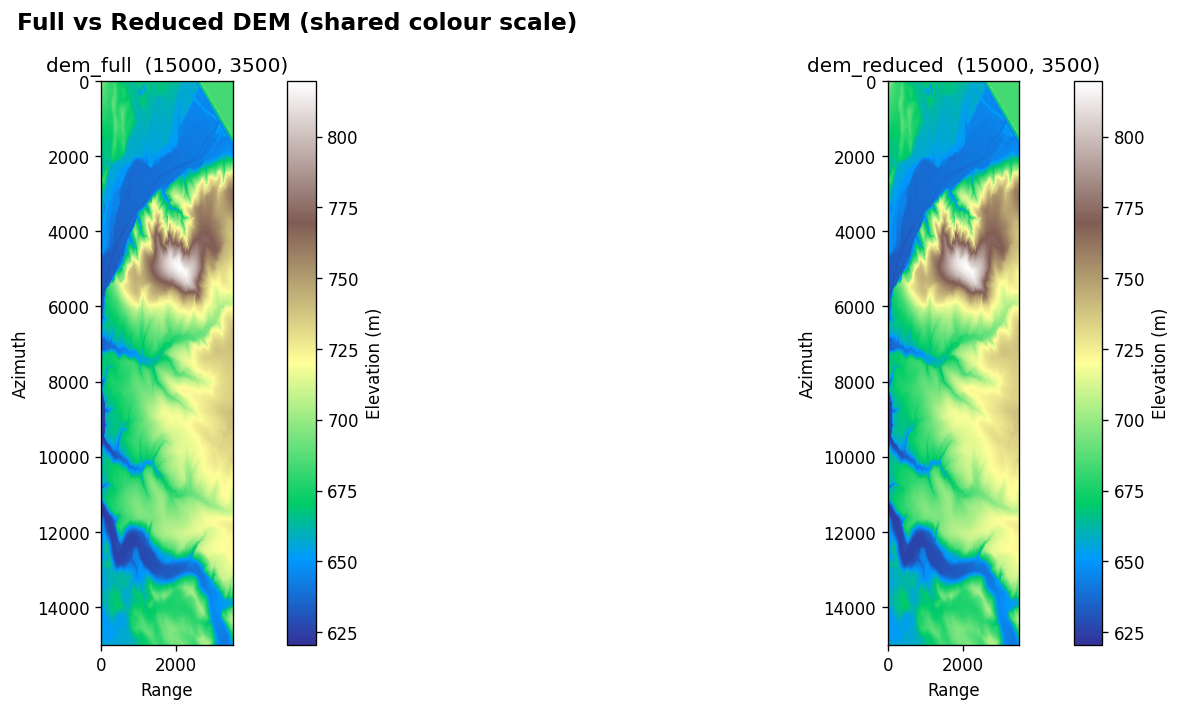

In [6]:
def to_2d(arr):
    if arr.ndim == 3:
        return arr[..., 0] if arr.shape[-1] < arr.shape[0] else arr[0]
    return arr

full_2d    = to_2d(dem_full)
reduced_2d = to_2d(dem_reduced)

print("Spatial resolution comparison:")
print(f"  dem_full    : {full_2d.shape}  ({full_2d.shape[0] / reduced_2d.shape[0]:.2f}x rows, "
      f"{full_2d.shape[1] / reduced_2d.shape[1]:.2f}x cols vs reduced)")
print(f"  dem_reduced : {reduced_2d.shape}")

# Shared colour scale
vmin = min(np.nanmin(full_2d), np.nanmin(reduced_2d))
vmax = max(np.nanmax(full_2d), np.nanmax(reduced_2d))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, img, lbl in zip(axes, [full_2d, reduced_2d], ["dem_full", "dem_reduced"]):
    im = ax.imshow(img, cmap="terrain", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(f"{lbl}  {img.shape}", fontsize=12)
    ax.set_xlabel("Range")
    ax.set_ylabel("Azimuth")
    plt.colorbar(im, ax=ax, label="Elevation (m)")

plt.suptitle("Full vs Reduced DEM (shared colour scale)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Histogram of Elevation Values

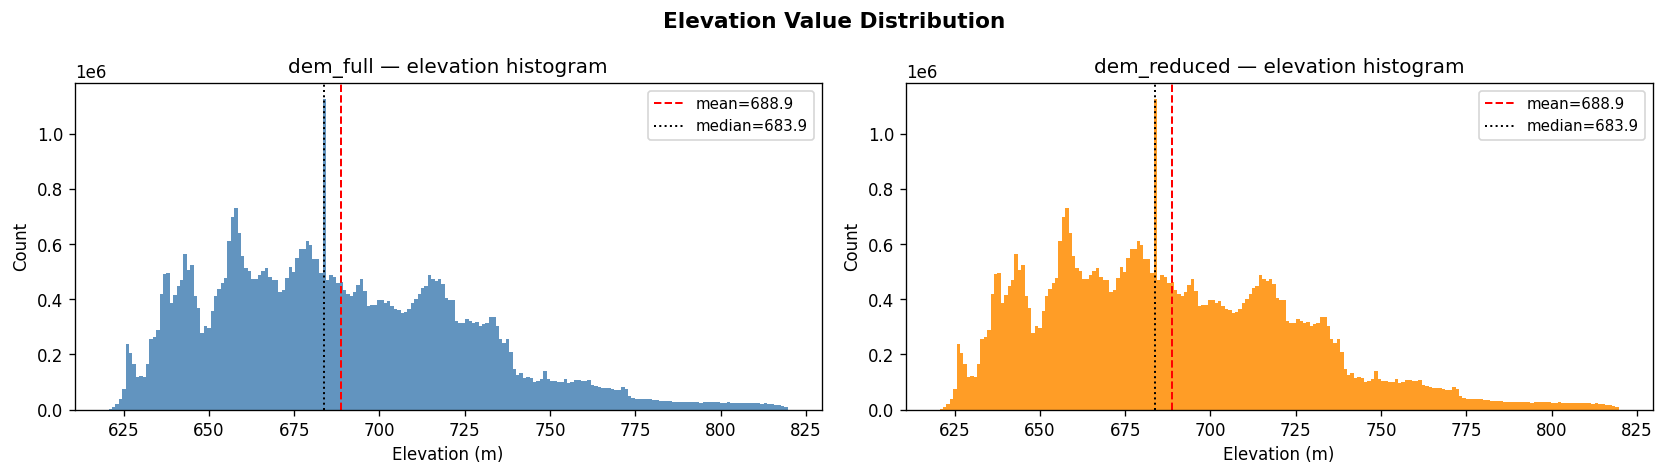

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, arr, name, color in zip(
    axes,
    [dem_full, dem_reduced],
    ["dem_full", "dem_reduced"],
    ["steelblue", "darkorange"]
):
    valid = arr.ravel()
    valid = valid[np.isfinite(valid)]
    ax.hist(valid, bins=200, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(valid.mean(), color="red",   linestyle="--", linewidth=1.2, label=f"mean={valid.mean():.1f}")
    ax.axvline(np.median(valid), color="black", linestyle=":",  linewidth=1.2, label=f"median={np.median(valid):.1f}")
    ax.set_title(f"{name} — elevation histogram")
    ax.set_xlabel("Elevation (m)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("Elevation Value Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
